<a href="https://colab.research.google.com/github/DanielWill-1/Capstone-Project---using-Hybrid-Vision-Transformers-for-Diabetic-Retinopathy-Staging/blob/main/Fundus%2BOCT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kermany2018' dataset.
Path to dataset files: /kaggle/input/kermany2018


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mariaherrerot/aptos2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'aptos2019' dataset.
Path to dataset files: /kaggle/input/aptos2019


In [ ]:
# ===============================
# Dual-Level Hybrid Fusion Framework for DR Staging
# End-to-End Training Code (Google Colab Ready)
# ===============================

!pip install timm einops scikit-learn matplotlib

import os, random, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torchvision.datasets as datasets
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score
import matplotlib.pyplot as plt
import timm
from einops import rearrange

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 5   # DR staging (0–4)
BATCH_SIZE = 32
EPOCHS = 5  # For demo; increase in real training
SAVE_DIR = "./weights"
os.makedirs(SAVE_DIR, exist_ok=True)

import pandas as pd
from PIL import Image

# ===============================
# Fundus Dataset (APTOS2019)
# ===============================
class FundusDataset(Dataset):
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = img_dir
        self.labels_df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["id_code"] + ".png")  # or .jpg
        image = Image.open(img_path).convert("RGB")
        label = int(row["diagnosis"])
        if self.transform:
            image = self.transform(image)
        return image, label

# ===============================
# OCT Dataset (Kermany OCT2017)
# ===============================
class OCTDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root, transform=transform)

# ===============================
# Dual Modal Dataset (Unpaired Sampling)
# ===============================
class DualModalDataset(Dataset):
    def __init__(self, fundus_ds, oct_ds):
        self.fundus_ds = fundus_ds
        self.oct_ds = oct_ds
        self.length = min(len(fundus_ds), len(oct_ds))  # balance
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        fundus_img, fundus_label = self.fundus_ds[idx]
        oct_img, oct_label = self.oct_ds[idx % len(self.oct_ds)]
        # we use fundus_label as the ground truth label for DR staging
        return fundus_img, oct_img, torch.tensor(fundus_label, dtype=torch.long)

# ===============================
# Apply Transforms
# ===============================
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

# Example paths (replace with your Drive paths)
fundus_root = "/kaggle/input/aptos2019/train_images/train_images"
fundus_csv  = "/kaggle/input/aptos2019/train_1.csv"
oct_root    = "/kaggle/input/kermany2018/OCT2017 /train"

fundus_ds = FundusDataset(fundus_root, fundus_csv, transform=transform)
oct_ds    = OCTDataset(oct_root, transform=transform)

train_ds = DualModalDataset(fundus_ds, oct_ds)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# ===============================
# Step 1: Experts (Fundus + OCT HViT)
# ===============================
class HViT(nn.Module):
    def __init__(self, backbone="efficientnet_b0", vit="vit_base_patch16_224", num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        self.vit = timm.create_model(vit, pretrained=True, num_classes=0)
        self.fc = nn.Linear(self.backbone.num_features + self.vit.num_features, num_classes)

    def forward(self, x):
        feat_cnn = self.backbone(x)
        feat_vit = self.vit(x)
        feat = torch.cat([feat_cnn, feat_vit], dim=1)
        out = self.fc(feat)
        return out, feat

fundus_expert = HViT().to(DEVICE)
oct_expert = HViT().to(DEVICE)

# ===============================
# Step 2: Feature-Level Fusion
# ===============================
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_classes=NUM_CLASSES):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key   = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.fc    = nn.Linear(dim, num_classes)

    def forward(self, f_fundus, f_oct):
        Q = self.query(f_fundus)
        K = self.key(f_oct)
        V = self.value(f_oct)
        attn = torch.softmax(Q @ K.T / (K.size(-1)**0.5), dim=-1)
        fused = attn @ V
        out = self.fc(fused)
        return out, fused

feature_fusion = CrossAttentionFusion(
    dim=fundus_expert.backbone.num_features + fundus_expert.vit.num_features,
    num_classes=NUM_CLASSES
).to(DEVICE)

# ===============================
# Step 3: Decision-Level Fusion (Meta-Learner)
# ===============================
class MetaLearner(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, p_fundus, p_oct, p_fused):
        combined = torch.cat([p_fundus, p_oct, p_fused], dim=1)
        return self.mlp(combined)

meta_learner = MetaLearner().to(DEVICE)

# ===============================
# Contrastive Loss (Label-guided)
# ===============================
def contrastive_loss(f_fundus, f_oct, labels, temperature=0.5):
    sim = F.cosine_similarity(f_fundus.unsqueeze(1), f_oct.unsqueeze(0), dim=-1)
    mask = torch.eq(labels.unsqueeze(1), labels.unsqueeze(0)).float()
    sim = sim / temperature
    loss = -torch.log(torch.exp(sim*mask).sum(1) / torch.exp(sim).sum(1))
    return loss.mean()

# ===============================
# Training & Evaluation Utilities
# ===============================
def evaluate(loader, models):
    fundus_expert, oct_expert, feature_fusion, meta_learner = models
    fundus_expert.eval(); oct_expert.eval(); feature_fusion.eval(); meta_learner.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for fundus, octimg, labels in loader:
            fundus, octimg, labels = fundus.to(DEVICE), octimg.to(DEVICE), labels.to(DEVICE)
            p_fundus, f_fundus = fundus_expert(fundus)
            p_oct, f_oct = oct_expert(octimg)
            p_fused, _ = feature_fusion(f_fundus, f_oct)
            p_meta = meta_learner(p_fundus, p_oct, p_fused)
            preds = torch.argmax(p_meta, dim=1).cpu().numpy()
            all_preds.extend(preds); all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return acc, kappa

def train_stage(stage, loader, models, opts, epochs=EPOCHS):
    fundus_expert, oct_expert, feature_fusion, meta_learner = models
    ce = nn.CrossEntropyLoss()
    history = {"loss": [], "acc": [], "kappa": []}
    for epoch in range(epochs):
        fundus_expert.train(); oct_expert.train(); feature_fusion.train(); meta_learner.train()
        epoch_loss = 0
        for fundus, octimg, labels in loader:
            fundus, octimg, labels = fundus.to(DEVICE), octimg.to(DEVICE), labels.to(DEVICE)
            for opt in opts: opt.zero_grad()

            # Stage logic
            if stage == 1:
                p_fundus, _ = fundus_expert(fundus)
                p_oct, _ = oct_expert(octimg)
                loss = ce(p_fundus, labels) + ce(p_oct, labels)

            elif stage == 2:
                with torch.no_grad():
                    _, f_fundus = fundus_expert(fundus)
                    _, f_oct = oct_expert(octimg)
                p_fused, fused_embed = feature_fusion(f_fundus, f_oct)
                loss = ce(p_fused, labels) + 0.1*contrastive_loss(f_fundus, f_oct, labels)

            elif stage == 3:
                p_fundus, f_fundus = fundus_expert(fundus)
                p_oct, f_oct = oct_expert(octimg)
                p_fused, fused_embed = feature_fusion(f_fundus, f_oct)
                p_meta = meta_learner(p_fundus, p_oct, p_fused)
                loss = ce(p_meta, labels)

            loss.backward()
            for opt in opts: opt.step()
            epoch_loss += loss.item()

        acc, kappa = evaluate(loader, models)
        history["loss"].append(epoch_loss/len(loader))
        history["acc"].append(acc)
        history["kappa"].append(kappa)
        print(f"[Stage {stage}] Epoch {epoch+1}/{epochs} Loss={epoch_loss/len(loader):.4f} Acc={acc:.3f} Kappa={kappa:.3f}")
    return history

# ===============================
# Optimizers
# ===============================
opt_f = torch.optim.Adam(fundus_expert.parameters(), lr=1e-4)
opt_o = torch.optim.Adam(oct_expert.parameters(), lr=1e-4)
opt_ff = torch.optim.Adam(feature_fusion.parameters(), lr=1e-4)
opt_m = torch.optim.Adam(meta_learner.parameters(), lr=1e-4)

# ===============================
# Train in 3 Stages
# ===============================
history1 = train_stage(1, train_loader, [fundus_expert, oct_expert, feature_fusion, meta_learner], [opt_f, opt_o])
history2 = train_stage(2, train_loader, [fundus_expert, oct_expert, feature_fusion, meta_learner], [opt_ff])
history3 = train_stage(3, train_loader, [fundus_expert, oct_expert, feature_fusion, meta_learner], [opt_m])

# ===============================
# Save Weights
# ===============================
torch.save(fundus_expert.state_dict(), f"{SAVE_DIR}/fundus_expert.pth")
torch.save(oct_expert.state_dict(), f"{SAVE_DIR}/oct_expert.pth")
torch.save(feature_fusion.state_dict(), f"{SAVE_DIR}/feature_fusion.pth")
torch.save(meta_learner.state_dict(), f"{SAVE_DIR}/meta_learner.pth")

# ===============================
# Plot Training Curves
# ===============================
def plot_history(histories, title):
    for i, h in enumerate(histories, 1):
        plt.plot(h["loss"], label=f"Stage {i} Loss")
    plt.legend(); plt.title(title); plt.show()

plot_history([history1, history2, history3], "Loss Curve")

for metric in ["acc", "kappa"]:
    for i, h in enumerate([history1, history2, history3], 1):
        plt.plot(h[metric], label=f"Stage {i} {metric}")
    plt.legend(); plt.title(metric.upper()); plt.show()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
# Colab-ready: Dual-Level Hybrid Fusion Framework (Optimized, End-to-End)
# - Reduced model sizes, stable cross-attention (MultiheadAttention)
# - APTOS CSV reader + train/val/test split
# - OCT folder loader, subsampled to match APTOS length
# - 3-stage training (experts -> feature-fusion -> meta-learner)
# - Mixed precision, metrics, save weights, plots

!pip install -q timm einops scikit-learn matplotlib

import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import torchvision.datasets as datasets
import timm
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix

# -------------------------
# Config - EDIT THESE PATHS
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PRINT_FREQ = 20

# Replace with your Kaggle/Drive mounted paths
APTOS_IMG_DIR = "/kaggle/input/aptos2019/train_images/train_images"   # folder with images
APTOS_CSV    = "/kaggle/input/aptos2019/train_1.csv"                   # CSV with id_code, diagnosis
OCT_ROOT     = "/kaggle/input/kermany2018/OCT2017 /train"               # OCT folder (ImageFolder style)

OUT_DIR = "/content/weights"
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams (safer for Colab free GPU)
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS_STAGE1 = 4   # increase as needed
EPOCHS_STAGE2 = 6
EPOCHS_STAGE3 = 3
LR = 1e-4
SEED = 42

# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Datasets
# -------------------------
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class FundusDataset(Dataset):
    """APTOS-style dataset: images in one dir, labels in CSV with columns id_code, diagnosis"""
    def __init__(self, img_dir, csv_file, transform=None):
        self.img_dir = Path(img_dir)
        df = pd.read_csv(csv_file)
        # normalize column names (some APTOS csv variants have different names)
        if "id_code" not in df.columns:
            raise ValueError("CSV must contain 'id_code' column")
        if "diagnosis" not in df.columns:
            # try to detect alternative column names:
            possible = [c for c in df.columns if c.lower().startswith("diagn")]
            if possible:
                df = df.rename(columns={possible[0]: "diagnosis"})
            else:
                raise ValueError("CSV must contain 'diagnosis' column")
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname_png = self.img_dir / f"{row['id_code']}.png"
        fname_jpg = self.img_dir / f"{row['id_code']}.jpg"
        if fname_png.exists():
            p = fname_png
        elif fname_jpg.exists():
            p = fname_jpg
        else:
            # fallback try any extension
            matches = list(self.img_dir.glob(f"{row['id_code']}.*"))
            if len(matches) == 0:
                raise FileNotFoundError(f"Image for {row['id_code']} not found in {self.img_dir}")
            p = matches[0]
        img = Image.open(p).convert("RGB")
        label = int(row["diagnosis"])
        if self.transform: img = self.transform(img)
        return img, label

# OCT dataset via ImageFolder (expected folder structure: root/<class>/*.jpg)
class OCTDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root, transform=transform)

# Build datasets and splits
fundus_full = FundusDataset(APTOS_IMG_DIR, APTOS_CSV, transform=transform_train)
n = len(fundus_full)
print(f"APTOS dataset size: {n}")

# Simple stratified split by label (train/val/test)
def stratified_split(df, val_ratio=0.12, test_ratio=0.08, seed=SEED):
    # returns indices for train, val, test
    groups = df.groupby('diagnosis').indices
    train_idx, val_idx, test_idx = [], [], []
    for label, indices in groups.items():
        indices = list(indices)
        random.Random(seed).shuffle(indices)
        k_val = int(len(indices)*val_ratio)
        k_test = int(len(indices)*test_ratio)
        test_idx += indices[:k_test]
        val_idx += indices[k_test:k_test+k_val]
        train_idx += indices[k_test+k_val:]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(fundus_full.df, val_ratio=0.12, test_ratio=0.08)
train_fundus = Subset(fundus_full, train_idx)
val_fundus   = Subset(fundus_full, val_idx)
test_fundus  = Subset(fundus_full, test_idx)
print("Split sizes (train/val/test):", len(train_fundus), len(val_fundus), len(test_fundus))

# OCT dataset and subsample to match fundus sizes (unpaired)
oct_full = OCTDataset(OCT_ROOT, transform=transform_train)
print("OCT total size:", len(oct_full))

# We'll subsample OCT to match training fundus size for efficiency (unpaired)
def subsample_dataset(ds, target_len, seed=SEED):
    idx = list(range(len(ds)))
    random.Random(seed).shuffle(idx)
    sel = idx[:target_len]
    return Subset(ds, sel)

oct_train_sub = subsample_dataset(oct_full, len(train_fundus))
oct_val_sub   = subsample_dataset(oct_full, len(val_fundus), seed=SEED+1)
oct_test_sub  = subsample_dataset(oct_full, len(test_fundus), seed=SEED+2)
print("Subsampled OCT sizes:", len(oct_train_sub), len(oct_val_sub), len(oct_test_sub))

# Dual dataset for unpaired sampling
class DualModalDataset(Dataset):
    def __init__(self, fundus_subset: Subset, oct_subset: Subset, transform_f=None, transform_o=None):
        self.fundus = fundus_subset
        self.oct = oct_subset
        self.len = min(len(self.fundus), len(self.oct))
    def __len__(self):
        return self.len
    def __getitem__(self, idx):
        fundus_img, fundus_label = self.fundus[idx]
        oct_img, _ = self.oct[idx % len(self.oct)]
        return fundus_img, oct_img, torch.tensor(fundus_label, dtype=torch.long)

train_ds = DualModalDataset(train_fundus, oct_train_sub)
val_ds   = DualModalDataset(val_fundus, oct_val_sub)
test_ds  = DualModalDataset(test_fundus, oct_test_sub)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------
# Models (lighter)
# -------------------------
class HViT_Small(nn.Module):
    """
    EfficientNet-B0 backbone (features) + ViT-Tiny (small) features concatenated -> classifier head
    """
    def __init__(self, backbone="efficientnet_b0", vit="vit_tiny_patch16_224", num_classes=NUM_CLASSES):
        super().__init__()
        # EfficientNet-B0 (no classifier)
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        # ViT tiny
        self.vit = timm.create_model(vit, pretrained=True, num_classes=0)
        # feature dimensions
        dim = self.backbone.num_features + self.vit.num_features
        self.head = nn.Linear(dim, num_classes)
        self.feat_dim = dim

    def forward(self, x):
        f1 = self.backbone(x)  # [B, F1]
        f2 = self.vit(x)       # [B, F2]
        feat = torch.cat([f1, f2], dim=1)
        out = self.head(feat)
        return out, feat

# Fusion using MultiheadAttention
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_classes=NUM_CLASSES, heads=4):
        super().__init__()
        # multihead attention expects sequences; we'll use seq_len=1 for each modality
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.fc = nn.Linear(dim, num_classes)
        self.dim = dim

    def forward(self, feat_fundus, feat_oct):
        # feat_* : [B, D]
        q = feat_fundus.unsqueeze(1)  # [B,1,D]
        kv = feat_oct.unsqueeze(1)    # [B,1,D]
        fused, attn_weights = self.attn(q, kv, kv)  # fused: [B,1,D]
        fused = fused.squeeze(1)
        out = self.fc(fused)
        return out, fused

class MetaLearner(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # takes soft logits/probabilities from 3 sources (fundus, oct, fused)
        self.mlp = nn.Sequential(
            nn.Linear(num_classes*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, p_fundus, p_oct, p_fused):
        # p_* are raw logits [B, C]
        x = torch.cat([p_fundus, p_oct, p_fused], dim=1)
        return self.mlp(x)

# Instantiate
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_learner  = MetaLearner().to(DEVICE)

# -------------------------
# Losses and utilities
# -------------------------
ce_loss = nn.CrossEntropyLoss()

# Label-guided contrastive (batch NT-Xent / supervised contrastive simplified)
def supervised_contrastive_loss(feat_a, feat_b, labels, temperature=0.5, eps=1e-8):
    """
    feat_a: [B, D], feat_b: [B, D], labels: [B]
    We compute similarity matrix between feat_a and feat_b:
      sim[i,j] = cosine(feat_a[i], feat_b[j]) / temp
    Positive mask: labels[i] == labels[j]
    Loss for each i: -log( sum_j exp(sim[i,j]) * mask[i,j] / sum_j exp(sim[i,j]) )
    """
    feat_a = F.normalize(feat_a, dim=1)
    feat_b = F.normalize(feat_b, dim=1)
    sim = torch.matmul(feat_a, feat_b.T) / temperature  # [B,B]
    labels = labels.contiguous().view(-1,1)
    mask_pos = (labels == labels.T).float().to(sim.device)
    # For numerical stability:
    exp_sim = torch.exp(sim)  # [B,B]
    pos_exp = exp_sim * mask_pos
    # sum over positives for each row
    pos_sum = pos_exp.sum(dim=1) + eps
    all_sum = exp_sim.sum(dim=1) + eps
    loss = -torch.log(pos_sum / all_sum)
    return loss.mean()

# Metrics
def compute_metrics_all(y_true, y_pred, logits=None):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    # AUC: for multiclass, use 'ovo' average if probabilities provided
    auc = None
    if logits is not None:
        try:
            from sklearn.preprocessing import label_binarize
            probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
            y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
            if y_true_bin.shape[1] == probs.shape[1]:
                auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovo')
        except Exception:
            auc = None
    return {"acc": acc, "kappa": kappa, "auc": auc}

def sens_spec_from_confmat(y_true, y_pred, class_id):
    # sensitivity = TP/(TP+FN) ; specificity = TN/(TN+FP)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    TP = cm[class_id, class_id]
    FN = cm[class_id, :].sum() - TP
    FP = cm[:, class_id].sum() - TP
    TN = cm.sum() - (TP+FN+FP)
    sens = TP / (TP+FN) if (TP+FN)>0 else 0.0
    spec = TN / (TN+FP) if (TN+FP)>0 else 0.0
    return sens, spec

# -------------------------
# Training loops (stages)
# -------------------------
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))

def evaluate(loader, models):
    fundus_expert, oct_expert, fusion_module, meta_learner = models
    fundus_expert.eval(); oct_expert.eval(); fusion_module.eval(); meta_learner.eval()
    all_labels = []
    all_preds = []
    all_logits = []
    with torch.no_grad():
        for f_img, o_img, labels in loader:
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); labels = labels.to(DEVICE)
            p_f, feat_f = fundus_expert(f_img)
            p_o, feat_o = oct_expert(o_img)
            p_fu, feat_fu = fusion_module(feat_f, feat_o)
            p_meta = meta_learner(p_f, p_o, p_fu)
            preds = torch.argmax(p_meta, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_logits.append(p_meta.cpu().numpy())
    logits = np.vstack(all_logits) if len(all_logits)>0 else None
    metrics = compute_metrics_all(all_labels, all_preds, logits=logits)
    return metrics, all_labels, all_preds

def train_stage_1(epochs, train_loader, val_loader, models, lr=LR):
    # Train experts only (fundus_expert and oct_expert)
    fundus_expert, oct_expert, fusion_module, meta_learner = models
    # Keep fusion & meta in eval/frozen
    fusion_module.eval(); meta_learner.eval()
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_learner.parameters(): p.requires_grad=False
    # Enable experts
    for p in fundus_expert.parameters(): p.requires_grad=True
    for p in oct_expert.parameters(): p.requires_grad=True

    opt = torch.optim.Adam(list(fundus_expert.parameters()) + list(oct_expert.parameters()), lr=lr)
    history = {"train_loss":[], "val_acc":[], "val_kappa":[]}
    for epoch in range(epochs):
        fundus_expert.train(); oct_expert.train()
        running_loss = 0.0
        for i, (f_img, o_img, labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); labels = labels.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                p_f, _ = fundus_expert(f_img)
                p_o, _ = oct_expert(o_img)
                loss = ce_loss(p_f, labels) + ce_loss(p_o, labels)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage1][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        # validation
        metrics, _, _ = evaluate(val_loader, models)
        print(f"[Stage1][Epoch {epoch+1}] TrainLoss={running_loss/len(train_loader):.4f} ValAcc={metrics['acc']:.4f} ValKappa={metrics['kappa']:.4f} AUC={metrics['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc"].append(metrics['acc'])
        history["val_kappa"].append(metrics['kappa'])
    return history

def train_stage_2(epochs, train_loader, val_loader, models, lr=LR):
    # Train fusion_module only (experts frozen). Use supervised contrastive + CE on fused output.
    fundus_expert, oct_expert, fusion_module, meta_learner = models
    fundus_expert.eval(); oct_expert.eval()
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=True
    for p in meta_learner.parameters(): p.requires_grad=False
    opt = torch.optim.Adam(fusion_module.parameters(), lr=lr)
    history = {"train_loss":[], "val_acc":[], "val_kappa":[]}
    for epoch in range(epochs):
        fusion_module.train()
        running_loss = 0.0
        for i, (f_img, o_img, labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); labels = labels.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                # get features (no grad for experts)
                with torch.no_grad():
                    p_f, feat_f = fundus_expert(f_img)
                    p_o, feat_o = oct_expert(o_img)
                p_fused, fused_feat = fusion_module(feat_f, feat_o)
                loss_ce = ce_loss(p_fused, labels)
                loss_ctr = supervised_contrastive_loss(feat_f, feat_o, labels, temperature=0.5)
                loss = loss_ce + 0.1 * loss_ctr
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage2][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _ = evaluate(val_loader, models)
        print(f"[Stage2][Epoch {epoch+1}] TrainLoss={running_loss/len(train_loader):.4f} ValAcc={metrics['acc']:.4f} ValKappa={metrics['kappa']:.4f} AUC={metrics['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc"].append(metrics['acc'])
        history["val_kappa"].append(metrics['kappa'])
    return history

def train_stage_3(epochs, train_loader, val_loader, models, lr=LR):
    # Train meta-learner only (experts + fusion frozen)
    fundus_expert, oct_expert, fusion_module, meta_learner = models
    for p in fundus_expert.parameters(): p.requires_grad=False
    for p in oct_expert.parameters(): p.requires_grad=False
    for p in fusion_module.parameters(): p.requires_grad=False
    for p in meta_learner.parameters(): p.requires_grad=True
    opt = torch.optim.Adam(meta_learner.parameters(), lr=lr)
    history = {"train_loss":[], "val_acc":[], "val_kappa":[]}
    for epoch in range(epochs):
        meta_learner.train()
        running_loss = 0.0
        for i, (f_img, o_img, labels) in enumerate(train_loader):
            f_img = f_img.to(DEVICE); o_img = o_img.to(DEVICE); labels = labels.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                with torch.no_grad():
                    p_f, feat_f = fundus_expert(f_img)
                    p_o, feat_o = oct_expert(o_img)
                    p_fused, fused_feat = fusion_module(feat_f, feat_o)
                p_meta = meta_learner(p_f, p_o, p_fused)
                loss = ce_loss(p_meta, labels)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            running_loss += loss.item()
            if (i+1) % PRINT_FREQ == 0:
                print(f"[Stage3][Epoch {epoch+1}/{epochs}] Step {i+1}/{len(train_loader)} loss={running_loss/(i+1):.4f}")
        metrics, _, _ = evaluate(val_loader, models)
        print(f"[Stage3][Epoch {epoch+1}] TrainLoss={running_loss/len(train_loader):.4f} ValAcc={metrics['acc']:.4f} ValKappa={metrics['kappa']:.4f} AUC={metrics['auc']}")
        history["train_loss"].append(running_loss/len(train_loader))
        history["val_acc"].append(metrics['acc'])
        history["val_kappa"].append(metrics['kappa'])
    return history

# -------------------------
# Run 3-stage training
# -------------------------
models = (fundus_expert, oct_expert, fusion_module, meta_learner)
print("Starting Stage 1 (train experts)...")
hist1 = train_stage_1(EPOCHS_STAGE1, train_loader, val_loader, models, lr=LR)

print("Starting Stage 2 (train fusion module)...")
hist2 = train_stage_2(EPOCHS_STAGE2, train_loader, val_loader, models, lr=LR*0.5)

print("Starting Stage 3 (train meta-learner)...")
hist3 = train_stage_3(EPOCHS_STAGE3, train_loader, val_loader, models, lr=LR*0.5)

# -------------------------
# Save weights
# -------------------------
torch.save(fundus_expert.state_dict(), os.path.join(OUT_DIR, "fundus_expert.pth"))
torch.save(oct_expert.state_dict(), os.path.join(OUT_DIR, "oct_expert.pth"))
torch.save(fusion_module.state_dict(), os.path.join(OUT_DIR, "fusion_module.pth"))
torch.save(meta_learner.state_dict(), os.path.join(OUT_DIR, "meta_learner.pth"))
print("Saved weights to", OUT_DIR)

# -------------------------
# Final evaluation on test set
# -------------------------
test_metrics, y_true, y_pred = evaluate(test_loader, models)
print("Final Test metrics:", test_metrics)
# per-class sensitivity & specificity
for cls in range(NUM_CLASSES):
    s, sp = sens_spec_from_confmat(y_true, y_pred, cls)
    print(f"Class {cls}: Sensitivity={s:.3f}, Specificity={sp:.3f}")

# -------------------------
# Plot training curves (combined)
# -------------------------
def plot_histories(h1, h2, h3):
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.plot(h1['train_loss'], label='Stage1')
    plt.plot(h2['train_loss'], label='Stage2')
    plt.plot(h3['train_loss'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.title('Train Loss')

    plt.subplot(1,3,2)
    plt.plot(h1['val_acc'], label='Stage1')
    plt.plot(h2['val_acc'], label='Stage2')
    plt


APTOS dataset size: 2930
Split sizes (train/val/test): 2348 350 232
OCT total size: 83484
Subsampled OCT sizes: 2348 350 232


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Starting Stage 1 (train experts)...


/tmp/ipython-input-1041170694.py:306: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-1041170694.py:348: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


...

[Stage3][Epoch 2/3] Step 20/294 loss=0.6880
[Stage3][Epoch 2/3] Step 40/294 loss=0.6669
[Stage3][Epoch 2/3] Step 60/294 loss=0.6624
[Stage3][Epoch 2/3] Step 80/294 loss=0.6415
[Stage3][Epoch 2/3] Step 100/294 loss=0.6290
[Stage3][Epoch 2/3] Step 120/294 loss=0.6326
[Stage3][Epoch 2/3] Step 140/294 loss=0.6183
[Stage3][Epoch 2/3] Step 160/294 loss=0.6174
[Stage3][Epoch 2/3] Step 180/294 loss=0.6122
[Stage3][Epoch 2/3] Step 200/294 loss=0.6021
[Stage3][Epoch 2/3] Step 220/294 loss=0.5941
[Stage3][Epoch 2/3] Step 240/294 loss=0.5882
[Stage3][Epoch 2/3] Step 260/294 loss=0.5810
[Stage3][Epoch 2/3] Step 280/294 loss=0.5733
[Stage3][Epoch 2] TrainLoss=0.5640 ValAcc=0.7743 ValKappa=0.8089 AUC=0.9238554583984591


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-1041170694.py:417: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


[Stage3][Epoch 3/3] Step 20/294 loss=0.4651
[Stage3][Epoch 3/3] Step 40/294 loss=0.4510
[Stage3][Epoch 3/3] Step 60/294 loss=0.4415
[Stage3][Epoch 3/3] Step 80/294 loss=0.4522
[Stage3][Epoch 3/3] Step 100/294 loss=0.4441
[Stage3][Epoch 3/3] Step 120/294 loss=0.4441
[Stage3][Epoch 3/3] Step 140/294 loss=0.4338
[Stage3][Epoch 3/3] Step 160/294 loss=0.4376
[Stage3][Epoch 3/3] Step 180/294 loss=0.4372
[Stage3][Epoch 3/3] Step 200/294 loss=0.4363
[Stage3][Epoch 3/3] Step 220/294 loss=0.4317
[Stage3][Epoch 3/3] Step 240/294 loss=0.4327
[Stage3][Epoch 3/3] Step 260/294 loss=0.4286
[Stage3][Epoch 3/3] Step 280/294 loss=0.4317
[Stage3][Epoch 3] TrainLoss=0.4339 ValAcc=0.7886 ValKappa=0.8337 AUC=0.9289577233353133
Saved weights to /content/weights


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Final Test metrics: {'acc': 0.7887931034482759, 'kappa': np.float64(0.8572326385251912), 'auc': np.float64(0.9183034849248202)}
Class 0: Sensitivity=1.000, Specificity=0.941
Class 1: Sensitivity=0.333, Specificity=0.976
Class 2: Sensitivity=0.875, Specificity=0.798
Class 3: Sensitivity=0.083, Specificity=0.991
Class 4: Sensitivity=0.222, Specificity=0.995


Fundus image: /kaggle/input/aptos2019/train_images/train_images/1ae8c165fd53.png
OCT image: /kaggle/input/kermany2018/OCT2017 /test/DME/DME-1081406-1.jpeg
Predicted class: Moderate (2)
Class probabilities: [0.05106773 0.06429546 0.7316835  0.05355949 0.09939387]


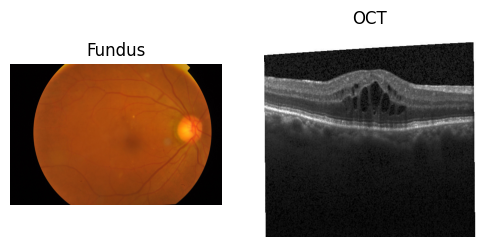

(2,
 array([0.05106773, 0.06429546, 0.7316835 , 0.05355949, 0.09939387],
       dtype=float32))

In [ ]:
# -------------------------
# Inference Cell
# -------------------------
from torchvision import transforms

# Reload models (in case of fresh Colab runtime)
fundus_expert = HViT_Small().to(DEVICE)
oct_expert    = HViT_Small().to(DEVICE)
fusion_module = CrossAttentionFusion(dim=fundus_expert.feat_dim).to(DEVICE)
meta_learner  = MetaLearner().to(DEVICE)

fundus_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "fundus_expert.pth"), map_location=DEVICE))
oct_expert.load_state_dict(torch.load(os.path.join(OUT_DIR, "oct_expert.pth"), map_location=DEVICE))
fusion_module.load_state_dict(torch.load(os.path.join(OUT_DIR, "fusion_module.pth"), map_location=DEVICE))
meta_learner.load_state_dict(torch.load(os.path.join(OUT_DIR, "meta_learner.pth"), map_location=DEVICE))

fundus_expert.eval(); oct_expert.eval(); fusion_module.eval(); meta_learner.eval()

# Preprocessing (same as validation)
inference_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

def predict_single(fundus_path, oct_path, class_names=None):
    # Load fundus
    fundus_img = Image.open(fundus_path).convert("RGB")
    f_tensor = inference_transform(fundus_img).unsqueeze(0).to(DEVICE)

    # Load OCT
    oct_img = Image.open(oct_path).convert("RGB")
    o_tensor = inference_transform(oct_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        p_f, feat_f = fundus_expert(f_tensor)
        p_o, feat_o = oct_expert(o_tensor)
        p_fu, feat_fu = fusion_module(feat_f, feat_o)
        p_meta = meta_learner(p_f, p_o, p_fu)

        probs = torch.softmax(p_meta, dim=1).cpu().numpy()[0]
        pred_class = int(np.argmax(probs))

    # Display
    print("Fundus image:", fundus_path)
    print("OCT image:", oct_path)
    if class_names:
        print(f"Predicted class: {class_names[pred_class]} ({pred_class})")
    else:
        print(f"Predicted class: {pred_class}")
    print("Class probabilities:", probs)

    # Show fundus and OCT side-by-side
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1); plt.imshow(fundus_img); plt.axis("off"); plt.title("Fundus")
    plt.subplot(1,2,2); plt.imshow(oct_img); plt.axis("off"); plt.title("OCT")
    plt.show()

    return pred_class, probs

# Example usage (edit paths to your test images)
fundus_example = "/kaggle/input/aptos2019/train_images/train_images/1ae8c165fd53.png"
oct_example    = "/kaggle/input/kermany2018/OCT2017 /test/DME/DME-1081406-1.jpeg"
predict_single(fundus_example, oct_example, class_names=["No DR","Mild","Moderate","Severe","Proliferative"])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score

# =============================
# 📊 EVALUATION ON TEST SET
# =============================
def evaluate_model(model, test_loader, stage_name="Final"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    print(f"[{stage_name}] Test Accuracy: {acc:.4f}")
    print(f"[{stage_name}] Quadratic Kappa: {kappa:.4f}")
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(NUM_CLASSES)))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{stage_name} Confusion Matrix")
    plt.show()

    return acc, kappa

# 🔎 Evaluate Meta-Learner (final stage)
final_acc, final_kappa = evaluate_model(meta, test_loader, "Stage3-MetaLearner")

# =============================
# 📈 TRAINING CURVES (if tracked)
# =============================
# You need to collect history dicts during training, e.g.,
# history["train_loss"], history["val_acc"], etc. while training.
# For demo, we'll just show structure.

def plot_curves(history):
    plt.figure(figsize=(12,5))

    # Loss Curve
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    # Accuracy Curve
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.show()

# Example usage (replace with your collected history dict)
# plot_curves(history_stage3)


NameError: name 'meta' is not defined

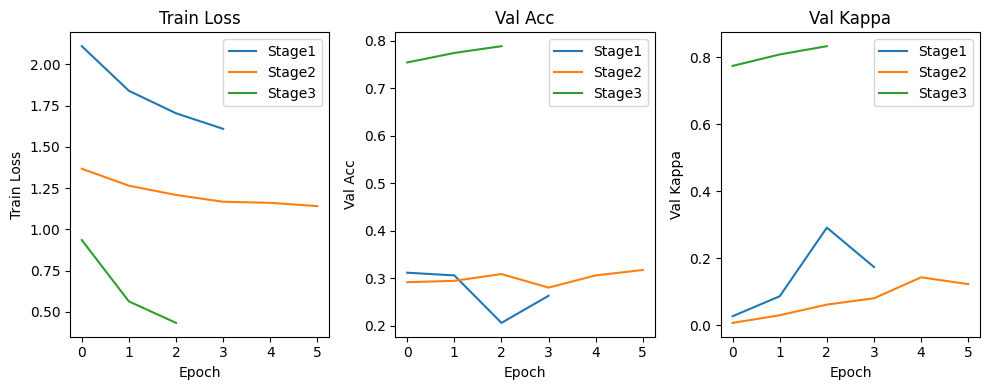

In [ ]:
# -------------------------
# Plot training curves (combined)
# -------------------------
def plot_histories(h1, h2, h3):
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.plot(h1['train_loss'], label='Stage1')
    plt.plot(h2['train_loss'], label='Stage2')
    plt.plot(h3['train_loss'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Train Loss'); plt.legend(); plt.title('Train Loss')

    plt.subplot(1,3,2)
    plt.plot(h1['val_acc'], label='Stage1')
    plt.plot(h2['val_acc'], label='Stage2')
    plt.plot(h3['val_acc'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Acc'); plt.legend(); plt.title('Val Acc')

    plt.subplot(1,3,3)
    plt.plot(h1['val_kappa'], label='Stage1')
    plt.plot(h2['val_kappa'], label='Stage2')
    plt.plot(h3['val_kappa'], label='Stage3')
    plt.xlabel('Epoch'); plt.ylabel('Val Kappa'); plt.legend(); plt.title('Val Kappa')
    plt.tight_layout()
    plt.show()

plot_histories(hist1, hist2, hist3)